# Pupil Labs Neon — Example Notebook

Full pyxations pipeline: BIDS organization → derivatives → `Experiment`.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "/home/gus/Documents/REPOS/pyxations")

from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt

import pyxations as pyx
from pyxations.formats.neon.bids import recording_to_bids

Error in sys.excepthook:
Traceback (most recent call last):
  File "/home/gus/Documents/envs/pyxations/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 1979, in showtraceback
    stb = value._render_traceback_()
AttributeError: 'RuntimeError' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/gus/Documents/envs/pyxations/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 1981, in showtraceback
    stb = self.InteractiveTB.structured_traceback(etype,
  File "/home/gus/Documents/envs/pyxations/lib/python3.10/site-packages/IPython/core/ultratb.py", line 1105, in structured_traceback
    return FormattedTB.structured_traceback(
  File "/home/gus/Documents/envs/pyxations/lib/python3.10/site-packages/IPython/core/ultratb.py", line 999, in structured_traceback
    return VerboseTB.structured_traceback(
  File "/home/gus/Documents/envs/pyxations

In [2]:
RECORDING_FOLDER    = Path("/tmp/neon_data/2026-03-27-15-12-46")
SCREEN_WIDTH        = 1600   # Neon scene camera
SCREEN_HEIGHT       = 1200
DETECTION_ALGORITHM = "neon"  # use device built-in events

DATASET_ROOT = Path("/home/gus/Documents/REPOS/pyxations/notebooks/neon_dataset")

## 2. Organize into BIDS + compute derivatives

In [3]:
# Reads wearer.json to extract subject/session IDs and builds the BIDS folder.
bids_folder = recording_to_bids(RECORDING_FOLDER, DATASET_ROOT)
print("BIDS folder:", bids_folder)

BIDS folder: /home/gus/Documents/REPOS/pyxations/notebooks/neon_dataset


In [ ]:
derivatives = pyx.compute_derivatives_for_dataset(
    bids_folder,
    dataset_format       = "neon",
    detection_algorithm  = DETECTION_ALGORITHM,
    overwrite            = False,   # set True to reprocess
)
print("Derivatives:", derivatives)

Derivatives: /home/gus/Documents/REPOS/pyxations/notebooks/neon_dataset_derivatives


## 3. Load with Experiment

In [5]:
exp = pyx.Experiment(bids_folder)
exp.load_data(DETECTION_ALGORITHM)

subj = list(exp.subjects.values())[0]
sess = list(subj.sessions.values())[0]

print(f"Subject: {subj.old_subject_id}  |  Session: {sess.session_id}")

Subject: 01  |  Session: 1


In [6]:
samples   = sess.samples()
fixations = sess.fixations()
saccades  = sess.saccades()

print(f"Samples:   {len(samples):>6}  ({samples['tSample'].max() / 1000:.1f} s)")
print(f"Fixations: {len(fixations):>6}  median duration {fixations['duration'].median():.0f} ms")
print(f"Saccades:  {len(saccades):>6}  median amplitude {saccades['ampDeg'].median():.1f}°")

Samples:    43010  (215.2 s)
Fixations:    412  median duration 283 ms
Saccades:     411  median amplitude 4.6°


In [7]:
fixations.head(5)

eye,tStart,tEnd,duration,xAvg,yAvg,pupilAvg,trial_number,trial_label,phase,session_id
str,f64,f64,f64,f64,f64,f64,i64,str,str,str
"""LR""",125.123,855.873,730.75,950.137329,393.532288,null,0,"""recording""","""recording""","""1"""
"""LR""",890.859,2147.086,1256.227,962.65863,403.362305,null,0,"""recording""","""recording""","""1"""
"""LR""",2177.086,2257.088,80.002,920.11499,392.47757,null,0,"""recording""","""recording""","""1"""
"""LR""",2292.209,3127.944,835.735,954.211121,395.848785,null,0,"""recording""","""recording""","""1"""
"""LR""",3162.943,4168.925,1005.982,920.911804,391.678497,null,0,"""recording""","""recording""","""1"""


In [8]:
saccades.head(5)

eye,tStart,tEnd,duration,xStart,yStart,xEnd,yEnd,ampDeg,vPeak,trial_number,trial_label,phase,session_id
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,str,str
"""LR""",855.873,890.859,34.986,941.02832,392.709473,982.473511,402.322205,2.728314,1600.559326,0,"""recording""","""recording""","""1"""
"""LR""",2147.086,2177.086,30.0,959.392578,394.60379,923.162231,389.530457,2.34807,1560.065552,0,"""recording""","""recording""","""1"""
"""LR""",2257.088,2292.209,35.121,919.187073,394.801819,971.58551,402.135284,3.396983,1980.135254,0,"""recording""","""recording""","""1"""
"""LR""",3127.944,3162.943,34.999,965.619934,399.908966,905.692993,397.319183,3.854157,2314.237061,0,"""recording""","""recording""","""1"""
"""LR""",4168.925,4188.924,19.999,934.609985,390.888885,951.475342,393.986664,1.100148,992.354797,0,"""recording""","""recording""","""1"""


## 4. Visualizations

In [9]:
vis = pyx.Visualization(sess.session_derivatives_path, DETECTION_ALGORITHM)

### 4.1 Scanpath

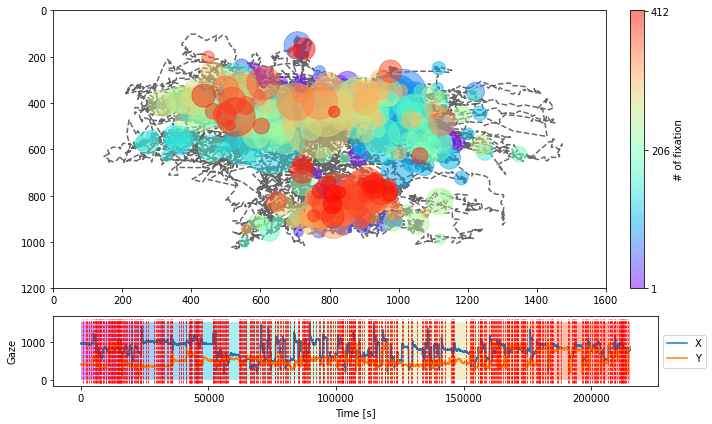

In [10]:
vis.scanpath(
    fixations,
    screen_height=SCREEN_HEIGHT,
    screen_width=SCREEN_WIDTH,
    saccades=saccades,
    samples=samples,
)

### 4.2 Fixation duration

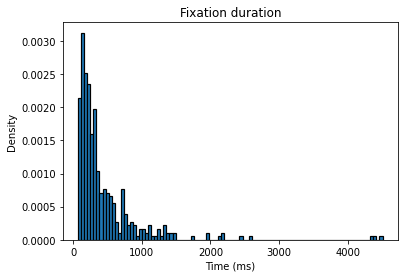

In [11]:
vis.fix_duration(fixations)

### 4.3 Saccade amplitude

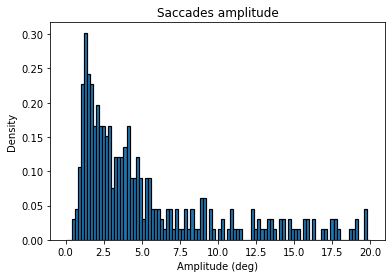

In [12]:
vis.sacc_amplitude(saccades)

### 4.4 Main sequence

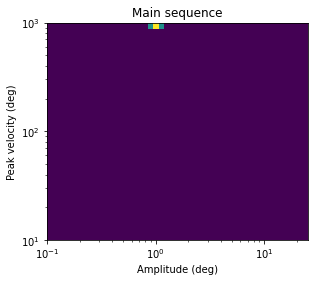

In [13]:
vis.sacc_main_sequence(saccades)

### 4.5 Saccade direction

ValueError: Compute saccades direction first by using saccades_direction function from the PreProcessing module.

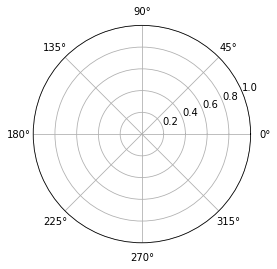

In [14]:
vis.sacc_direction(saccades)

### 4.6 Multipanel summary

In [ ]:
vis.plot_multipanel(fixations, saccades)

### 4.7 Raw gaze over time

In [ ]:
blinks    = pl.read_ipc(sess.session_derivatives_path / f"{DETECTION_ALGORITHM}_events/blink.feather")

df        = samples.to_pandas()
blinks_pd = blinks.to_pandas()
t         = df["tSample"].to_numpy() / 1000

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(t, df["X"].to_numpy(), lw=0.5, color="steelblue")
axes[0].set_ylabel("X (px)")
axes[0].set_ylim(0, SCREEN_WIDTH)
axes[1].plot(t, df["Y"].to_numpy(), lw=0.5, color="tomato")
axes[1].set_ylabel("Y (px)")
axes[1].set_ylim(0, SCREEN_HEIGHT)
axes[1].set_xlabel("Time (s)")
for _, b in blinks_pd.iterrows():
    for ax in axes:
        ax.axvspan(b["tStart"] / 1000, b["tEnd"] / 1000, alpha=0.2, color="gray")
axes[0].set_title("Raw gaze signal (gray = blinks)")
plt.tight_layout()
plt.show()

### 4.8 Pupil diameter over time

In [ ]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t, df["Pupil"].to_numpy(), lw=0.6, color="mediumpurple")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pupil diameter (mm)")
ax.set_title("Mean pupil diameter (L+R average)")
plt.tight_layout()
plt.show()